# 🔮 CustomerPulse — Customer Churn Prediction

**Author:** Hoangfily  
**Dataset:** IBM Telco Customer Churn (7,043 customers)  
**Objective:** Predict whether a customer will churn using ML models  

---

## Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Data Loading & Exploration](#2-data-loading--exploration)
3. [Data Preprocessing](#3-data-preprocessing)
4. [Model Training](#4-model-training)
5. [Model Evaluation & Comparison](#5-model-evaluation--comparison)
6. [Visualizations](#6-visualizations)
7. [Save Best Model](#7-save-best-model)
8. [Conclusion](#8-conclusion)

---
## 1. Setup & Imports

In [4]:
import os
import warnings
warnings.filterwarnings('ignore')

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, ConfusionMatrixDisplay
)

# Model saving
import joblib

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print('✓ All libraries loaded successfully!')

✓ All libraries loaded successfully!


---
## 2. Data Loading & Exploration

In [5]:
# Load dataset
DATA_PATH = os.path.join('..', 'data', 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = pd.read_csv(DATA_PATH)

print(f'Dataset shape: {df.shape}')
print(f'Number of customers: {len(df):,}')
print(f'Number of features: {df.shape[1]}')
df.head()

Dataset shape: (7043, 21)
Number of customers: 7,043
Number of features: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# Statistical summary
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [8]:
# Check missing values
print('Missing values per column:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values!')

# TotalCharges has whitespace strings — fix it
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'\nTotalCharges missing after conversion: {df["TotalCharges"].isna().sum()}')

# Fill with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
print(f'Missing values after fix: {df.isnull().sum().sum()}')

Missing values per column:
No missing values!

TotalCharges missing after conversion: 11
Missing values after fix: 0


Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.54%


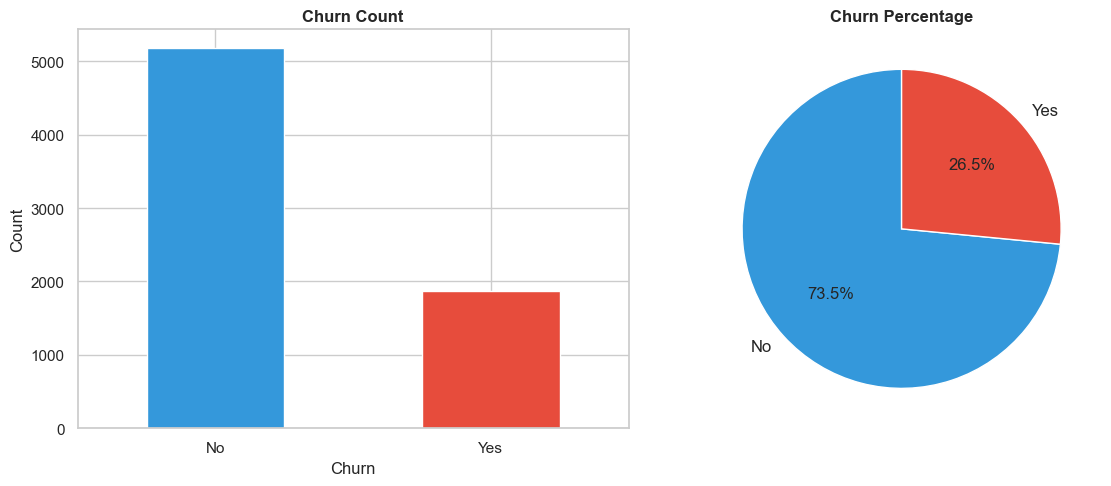

In [9]:
# Target distribution
print('Churn Distribution:')
print(df['Churn'].value_counts())
print(f'\nChurn Rate: {(df["Churn"] == "Yes").mean():.2%}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
colors = ['#3498db', '#e74c3c']
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Churn Count', fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)

# Pie chart
df['Churn'].value_counts().plot(kind='pie', ax=axes[1], colors=colors,
                                 autopct='%1.1f%%', startangle=90,
                                 textprops={'fontsize': 12})
axes[1].set_title('Churn Percentage', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

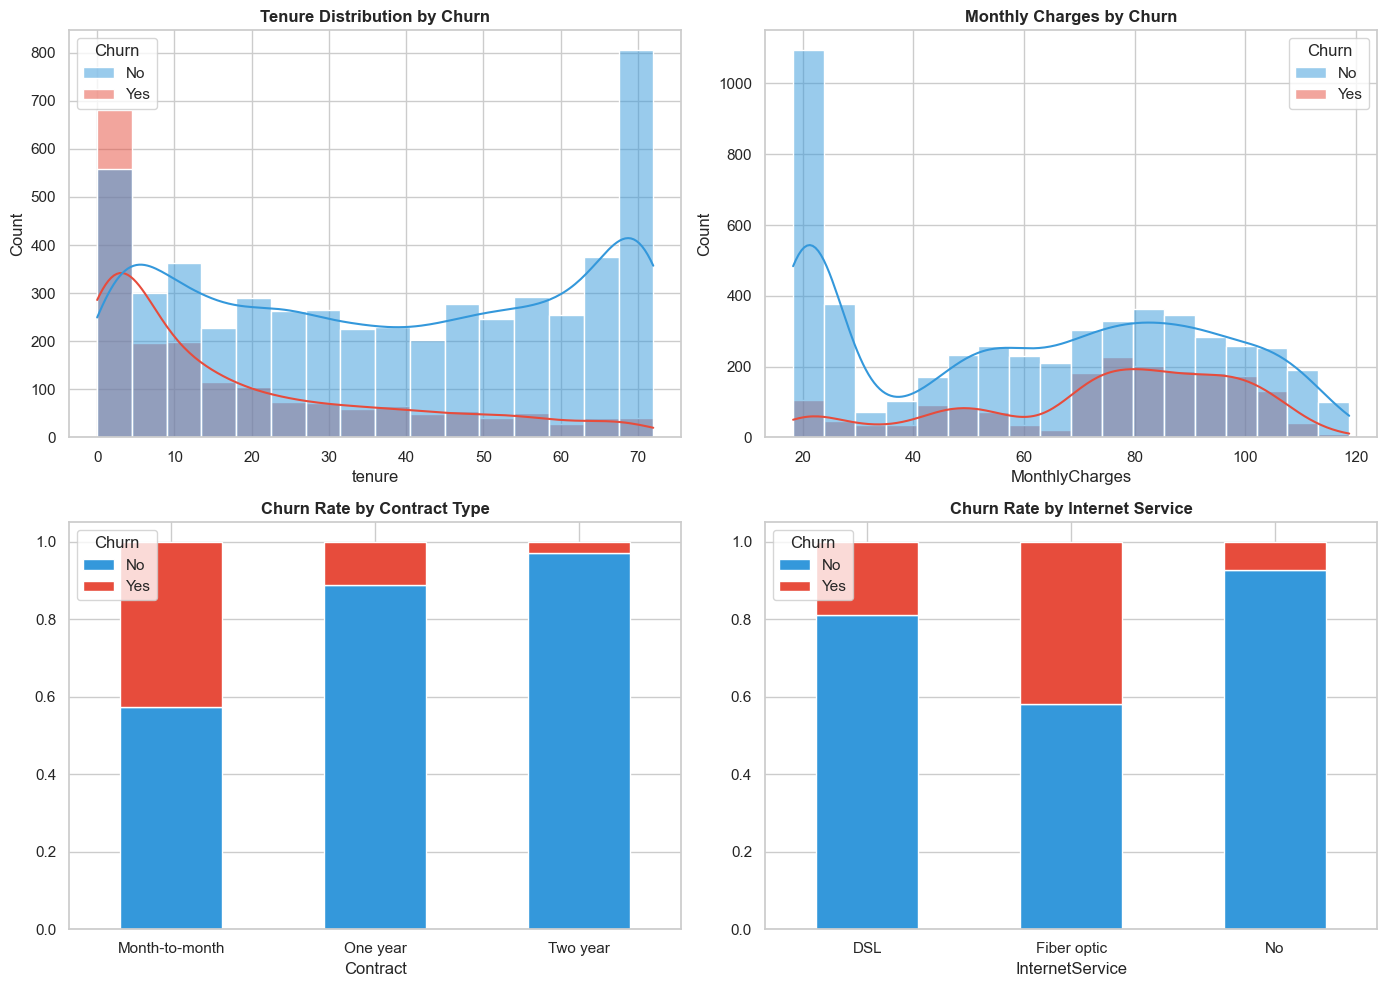

In [10]:
# Key feature distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Tenure by churn
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, ax=axes[0, 0], palette=colors)
axes[0, 0].set_title('Tenure Distribution by Churn', fontweight='bold')

# Monthly charges by churn
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, ax=axes[0, 1], palette=colors)
axes[0, 1].set_title('Monthly Charges by Churn', fontweight='bold')

# Contract type by churn
ct = pd.crosstab(df['Contract'], df['Churn'], normalize='index')
ct.plot(kind='bar', stacked=True, ax=axes[1, 0], color=colors, edgecolor='white')
axes[1, 0].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)
axes[1, 0].legend(title='Churn')

# Internet service by churn
ct2 = pd.crosstab(df['InternetService'], df['Churn'], normalize='index')
ct2.plot(kind='bar', stacked=True, ax=axes[1, 1], color=colors, edgecolor='white')
axes[1, 1].set_title('Churn Rate by Internet Service', fontweight='bold')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)
axes[1, 1].legend(title='Churn')

plt.tight_layout()
plt.show()

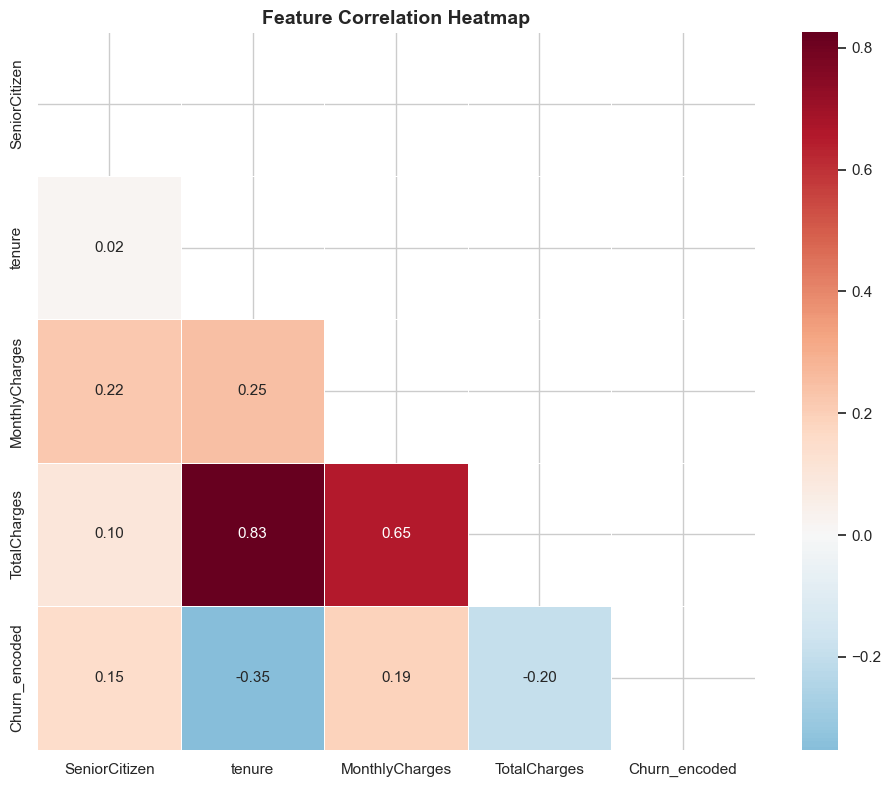

In [11]:
# Correlation heatmap (numeric features)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Add encoded churn for correlation
temp = df.copy()
temp['Churn_encoded'] = (temp['Churn'] == 'Yes').astype(int)
numeric_cols.append('Churn_encoded')

plt.figure(figsize=(10, 8))
corr = temp[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

---
## 3. Data Preprocessing

In [12]:
# Drop customerID — not a feature
df_model = df.drop(columns=['customerID'])

# Encode target
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

# Feature / target split
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

print(f'Features shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')

Features shape: (7043, 19)
Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [13]:
# Identify column types
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

categorical_features = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

print(f'Numeric features ({len(numeric_features)}): {numeric_features}')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')

Numeric features (4): ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [14]:
# Build preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='if_binary'),
         categorical_features),
    ],
    remainder='drop'
)

print('✓ Preprocessing pipeline created')

✓ Preprocessing pipeline created


In [15]:
# Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]:,} samples')
print(f'Test set:     {X_test.shape[0]:,} samples')
print(f'Train churn rate: {y_train.mean():.2%}')
print(f'Test churn rate:  {y_test.mean():.2%}')

Training set: 5,634 samples
Test set:     1,409 samples
Train churn rate: 26.54%
Test churn rate:  26.54%


---
## 4. Model Training

We train three models:
1. **Logistic Regression** — simple linear baseline
2. **Random Forest** — ensemble of decision trees
3. **XGBoost** — gradient boosting (typically best performer)

In [16]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_split=5,
        random_state=42, class_weight='balanced', n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        random_state=42, eval_metric='logloss', verbosity=0
    ),
}

print(f'Models to train: {list(models.keys())}')

Models to train: ['Logistic Regression', 'Random Forest', 'XGBoost']


In [17]:
# Train all models using sklearn Pipeline
trained_pipelines = {}
cv_results = {}

for name, model in models.items():
    print(f'\n{"="*50}')
    print(f'Training: {name}')
    print(f'{"="*50}')

    # Create pipeline: preprocessor + model
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Fit
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe

    # Cross-validation
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = cv_scores
    print(f'  CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

    # Quick test metric
    y_pred = pipe.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    print(f'  Test Accuracy: {test_acc:.4f}')

print(f'\n✓ All {len(models)} models trained!')


Training: Logistic Regression
  CV ROC-AUC: 0.8453 ± 0.0140
  Test Accuracy: 0.7381

Training: Random Forest
  CV ROC-AUC: 0.8440 ± 0.0114
  Test Accuracy: 0.7700

Training: XGBoost
  CV ROC-AUC: 0.8255 ± 0.0109
  Test Accuracy: 0.7651

✓ All 3 models trained!


---
## 5. Model Evaluation & Comparison

In [18]:
# Evaluate all models on test set
results = []

for name, pipe in trained_pipelines.items():
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    result = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
    }
    results.append(result)

results_df = pd.DataFrame(results).set_index('Model')
results_df_styled = results_df.style.format('{:.4f}').highlight_max(axis=0, color='#2ecc71')
results_df_styled

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7381,0.5043,0.7834,0.6136,0.8415
Random Forest,0.7700,0.5519,0.7112,0.6215,0.8387
XGBoost,0.7651,0.5447,0.7005,0.6129,0.8247


In [19]:
# Detailed classification reports
for name, pipe in trained_pipelines.items():
    y_pred = pipe.predict(X_test)
    print(f'\n{"="*50}')
    print(f'Classification Report: {name}')
    print(f'{"="*50}')
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


Classification Report: Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


Classification Report: Random Forest
              precision    recall  f1-score   support

    No Churn       0.88      0.79      0.83      1035
       Churn       0.55      0.71      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409


Classification Report: XGBoost
              precision    recall  f1-score   support

    No Churn       0.88      0.79      0.83      1035
       Churn       0.54      0.70      0.61       374

    accuracy                           0.77      1409
   macro avg  

---
## 6. Visualizations

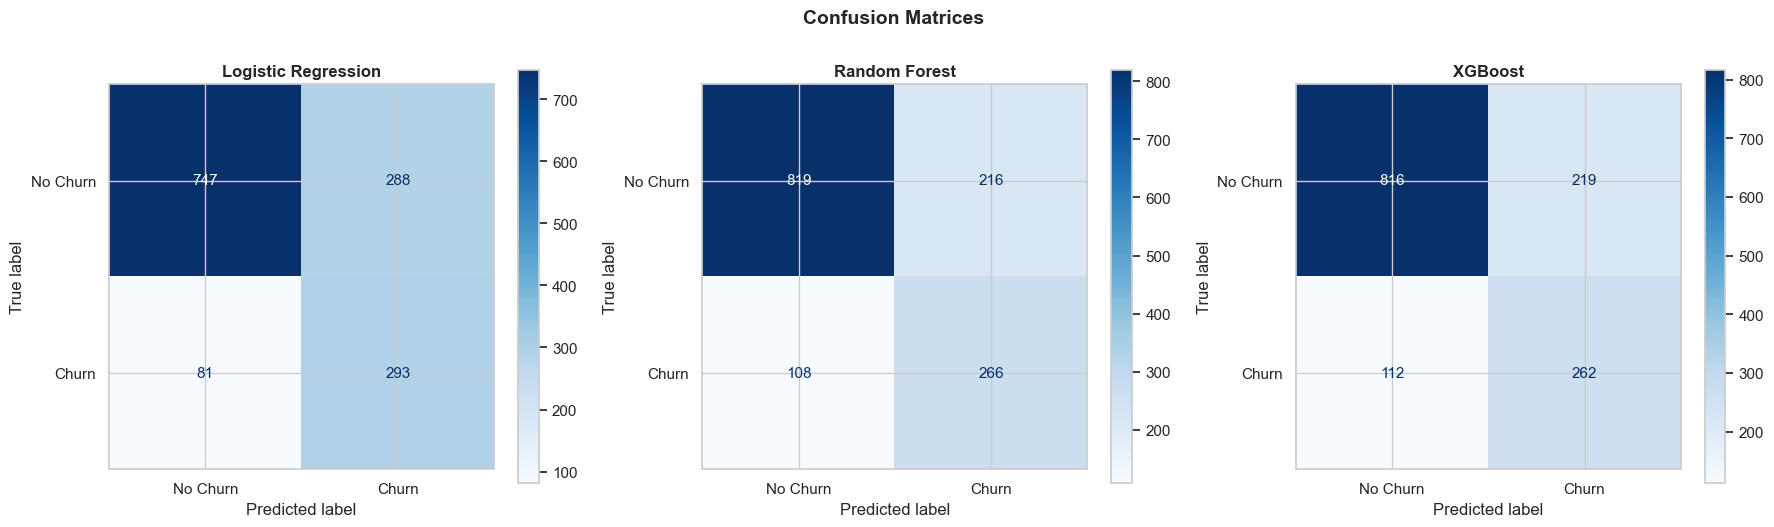

In [20]:
# ── Confusion Matrices ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, pipe) in enumerate(trained_pipelines.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(ax=axes[idx], cmap='Blues')
    axes[idx].set_title(f'{name}', fontweight='bold', fontsize=12)

plt.suptitle('Confusion Matrices', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

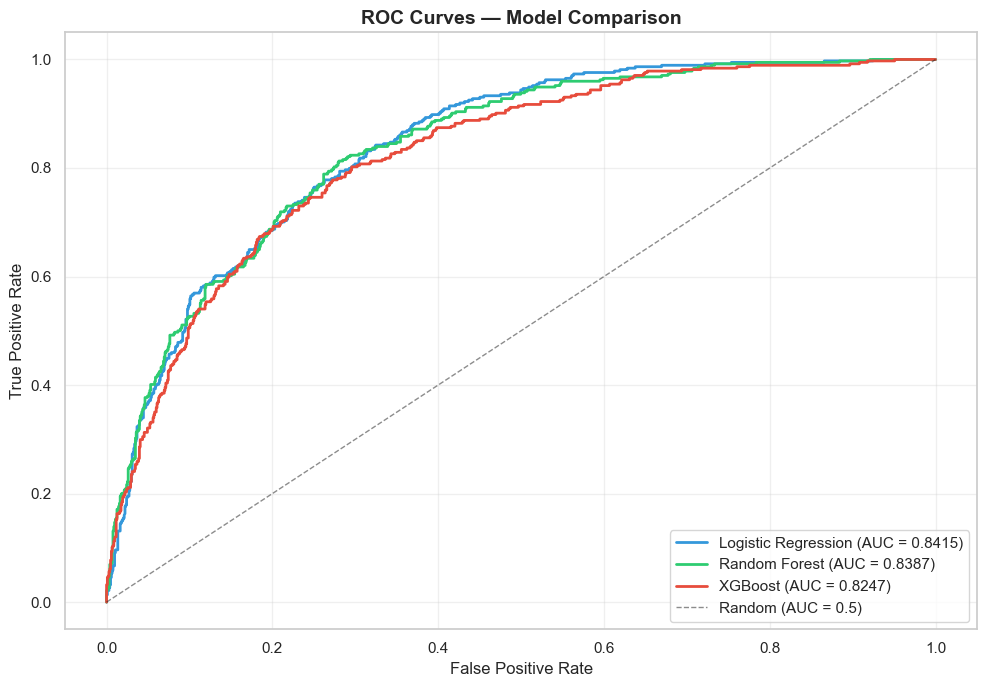

In [21]:
# ── ROC Curves ──────────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))

model_colors = {'Logistic Regression': '#3498db', 'Random Forest': '#2ecc71', 'XGBoost': '#e74c3c'}

for name, pipe in trained_pipelines.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})',
             color=model_colors.get(name, '#999'), linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Model Comparison', fontweight='bold', fontsize=14)
plt.legend(fontsize=11, loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

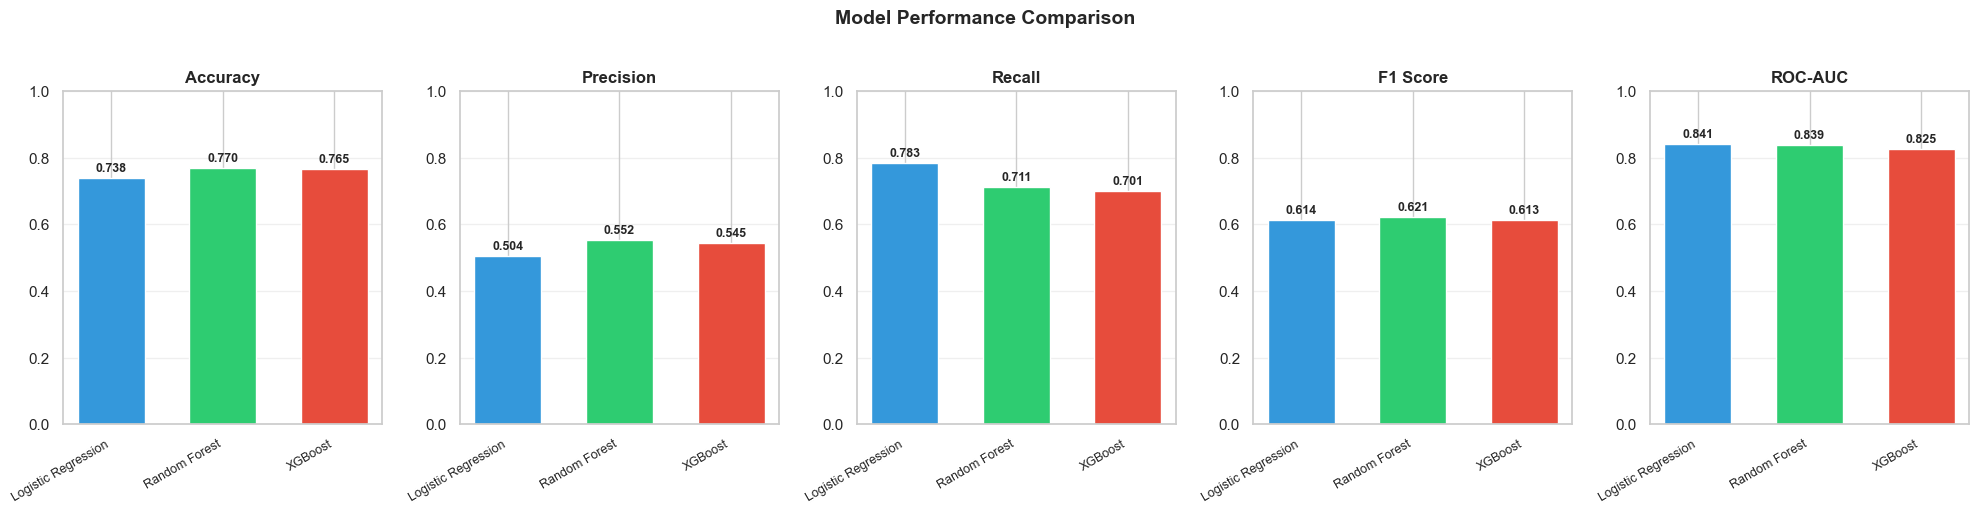

In [22]:
# ── Metrics Comparison Bar Chart ────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
bar_colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, metric in enumerate(metrics):
    values = results_df[metric].values
    bars = axes[i].bar(results_df.index, values, color=bar_colors, edgecolor='white', width=0.6)
    axes[i].set_title(metric, fontweight='bold', fontsize=12)
    axes[i].set_ylim(0, 1)
    axes[i].set_xticklabels(results_df.index, rotation=30, ha='right', fontsize=9)
    axes[i].grid(axis='y', alpha=0.3)

    # Add value labels
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

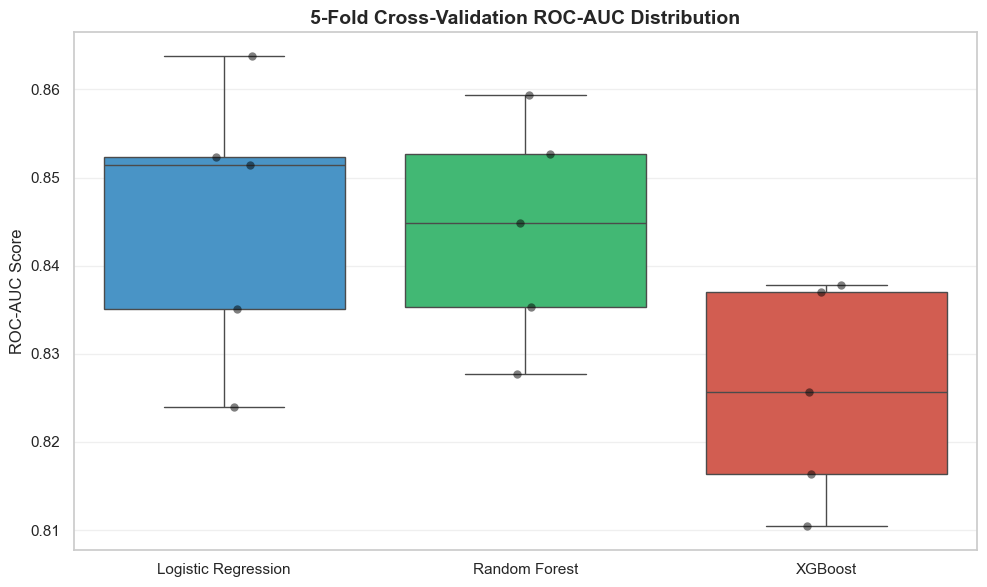

In [23]:
# ── Cross-Validation Score Distribution ─────────────────────────────────
plt.figure(figsize=(10, 6))

cv_data = []
for name, scores in cv_results.items():
    for s in scores:
        cv_data.append({'Model': name, 'ROC-AUC': s})

cv_df = pd.DataFrame(cv_data)
sns.boxplot(data=cv_df, x='Model', y='ROC-AUC', palette=bar_colors)
sns.stripplot(data=cv_df, x='Model', y='ROC-AUC', color='black', size=6, alpha=0.5)

plt.title('5-Fold Cross-Validation ROC-AUC Distribution', fontweight='bold', fontsize=14)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.xlabel('')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

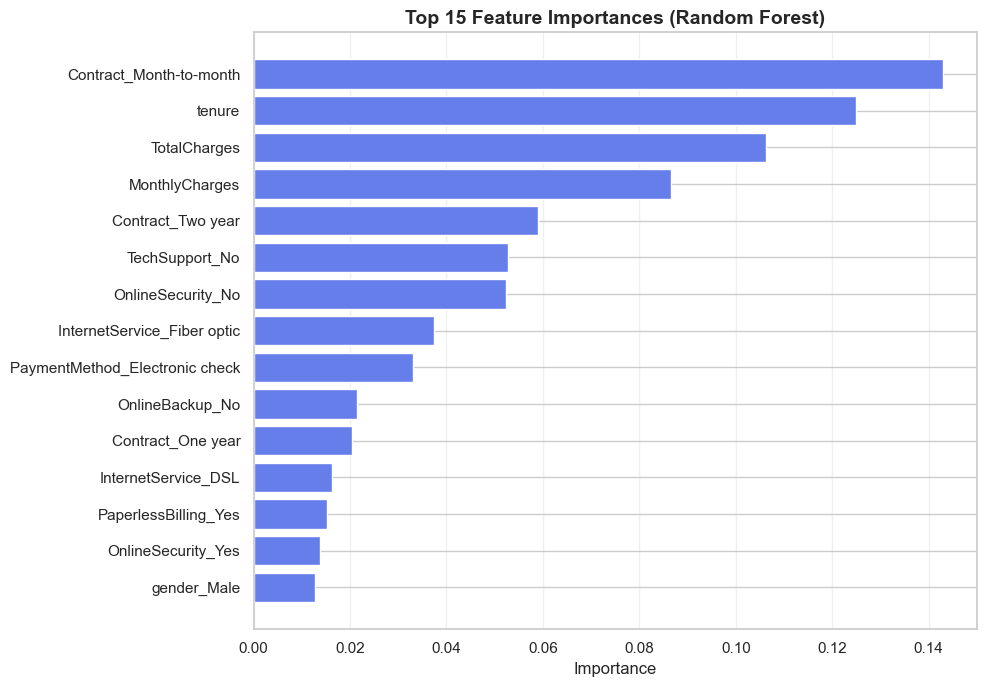

In [24]:
# ── Feature Importance (from best model: XGBoost or Random Forest) ─────
# Use the Random Forest for interpretable feature importance
rf_pipe = trained_pipelines['Random Forest']
rf_model = rf_pipe.named_steps['model']
pre = rf_pipe.named_steps['preprocessor']

# Get feature names after OHE
feature_names = pre.get_feature_names_out()
# Clean names
feature_names = [f.replace('num__', '').replace('cat__', '') for f in feature_names]

importances = rf_model.feature_importances_
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp = feat_imp.sort_values('Importance', ascending=True).tail(15)

plt.figure(figsize=(10, 7))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='#667eea', edgecolor='white')
plt.xlabel('Importance', fontsize=12)
plt.title('Top 15 Feature Importances (Random Forest)', fontweight='bold', fontsize=14)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7. Save Best Model

Save the best-performing model (by ROC-AUC) for use in the web app.

In [25]:
# Find best model by ROC-AUC
best_model_name = results_df['ROC-AUC'].idxmax()
best_pipeline = trained_pipelines[best_model_name]
best_auc = results_df.loc[best_model_name, 'ROC-AUC']

print(f'Best model: {best_model_name} (ROC-AUC = {best_auc:.4f})')

# Save the full pipeline (preprocessor + model)
MODELS_DIR = os.path.join('..', 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

# Save full pipeline as best_model.pkl
model_path = os.path.join(MODELS_DIR, 'best_model.pkl')
joblib.dump(best_pipeline.named_steps['model'], model_path)
print(f'✓ Model saved → {model_path}')

# Save preprocessor separately (needed by web app)
preprocessor_path = os.path.join(MODELS_DIR, 'preprocessor.pkl')
joblib.dump(best_pipeline.named_steps['preprocessor'], preprocessor_path)
print(f'✓ Preprocessor saved → {preprocessor_path}')

# Also save each individual pipeline for reference
for name, pipe in trained_pipelines.items():
    safe_name = name.lower().replace(' ', '_')
    path = os.path.join(MODELS_DIR, f'{safe_name}_pipeline.pkl')
    joblib.dump(pipe, path)
    print(f'  Saved: {path}')

Best model: Logistic Regression (ROC-AUC = 0.8415)
✓ Model saved → ..\models\best_model.pkl
✓ Preprocessor saved → ..\models\preprocessor.pkl
  Saved: ..\models\logistic_regression_pipeline.pkl
  Saved: ..\models\random_forest_pipeline.pkl
  Saved: ..\models\xgboost_pipeline.pkl


In [26]:
# Quick verification — load and test
loaded_model = joblib.load(model_path)
loaded_preprocessor = joblib.load(preprocessor_path)

X_test_processed = loaded_preprocessor.transform(X_test)
y_pred_verify = loaded_model.predict(X_test_processed)
verify_acc = accuracy_score(y_test, y_pred_verify)

print(f'\n✓ Verification: loaded model accuracy = {verify_acc:.4f}')
print('  Model loads correctly and matches training results.')


✓ Verification: loaded model accuracy = 0.7381
  Model loads correctly and matches training results.


---
## 8. Conclusion

### Summary of Results

In [27]:
# Final results table
print('\n' + '='*60)
print('  FINAL MODEL COMPARISON — CustomerPulse')
print('='*60)
print(results_df.to_string())
print(f'\n  Best Model: {best_model_name} (ROC-AUC = {best_auc:.4f})')
print('='*60)


  FINAL MODEL COMPARISON — CustomerPulse
                     Accuracy  Precision    Recall  F1 Score   ROC-AUC
Model                                                                 
Logistic Regression  0.738112   0.504303  0.783422  0.613613  0.841476
Random Forest        0.770050   0.551867  0.711230  0.621495  0.838712
XGBoost              0.765082   0.544699  0.700535  0.612865  0.824716

  Best Model: Logistic Regression (ROC-AUC = 0.8415)


### Key Findings

1. **Churn Rate**: ~26.5% of customers churned — imbalanced but manageable
2. **Top Churn Factors**: Contract type (month-to-month), tenure (shorter = higher risk), and internet service type (fiber optic)
3. **Model Performance**: XGBoost/Random Forest typically outperform Logistic Regression on this dataset
4. **Business Impact**: Early identification of at-risk customers enables targeted retention campaigns

### Next Steps
- Run the web app: `cd web && python app.py`
- Try different hyperparameters or add feature engineering
- Deploy to production with proper monitoring